In [ ]:
# Hosted D2L setup: fetch the exact helper module used to build this notebook.
from pathlib import Path
from urllib.request import urlretrieve
from importlib.metadata import PackageNotFoundError, version
import importlib.util, os, subprocess, sys

required = ['numpy', 'pandas', 'matplotlib', 'requests', 'scipy', 'pillow', 'regex', 'tensorflow', 'keras', 'protobuf', 'ml-dtypes']
imports = {'pillow': 'PIL', 'protobuf': 'google.protobuf', 'ml-dtypes': 'ml_dtypes'}
pinned = {}
fallbacks = {'tensorflow': 'tensorflow==2.21.0', 'keras': 'keras==3.14.0', 'protobuf': 'protobuf==7.34.1', 'ml-dtypes': 'ml-dtypes==0.5.4'}
device = os.environ.get("D2L_HOSTED_DEVICE", "auto").lower()
if device not in ("auto", "cpu", "gpu"):
    raise ValueError(f"Invalid D2L_HOSTED_DEVICE={device!r}")
if device == "auto":
    try:
        gpu = (Path("/dev/nvidia0").exists() or
               subprocess.run(["nvidia-smi", "-L"], capture_output=True,
                              timeout=5).returncode == 0)
    except (FileNotFoundError, subprocess.SubprocessError):
        gpu = False
else:
    gpu = device == "gpu"
if not gpu:
    os.environ.setdefault("CUDA_VISIBLE_DEVICES", "-1")
    os.environ.setdefault("JAX_PLATFORMS", "cpu")
tensorflow_version = None
if 'tensorflow' in ("tensorflow", "jax"):
    try:
        tensorflow_version = version("tensorflow")
    except PackageNotFoundError:
        pass
# Colab's CPU image currently carries a CUDA-enabled TensorFlow wheel. Its
# first ordinary tensor operation probes CUDA and emits an error-level cuInit
# diagnostic. JAX notebooks also use TensorFlow for data loading, so overlay
# the matching CPU build in both CPU variants. Keep the provider's
# ``tensorflow`` distribution metadata: other preinstalled Colab packages
# depend on that distribution name, while both wheels expose the same module.
if not gpu and 'tensorflow' in ("tensorflow", "jax"):
    try:
        tensorflow_cpu_version = version("tensorflow-cpu")
    except PackageNotFoundError:
        tensorflow_cpu_version = None
    if (tensorflow_version is not None and
            tensorflow_cpu_version != tensorflow_version):
        subprocess.check_call([
            sys.executable, "-m", "pip", "install", "-q", "--no-deps",
            f"tensorflow-cpu=={tensorflow_version}",
        ])
if "tf-keras" in fallbacks and tensorflow_version is not None:
    fallbacks["tf-keras"] = f"tf-keras=={tensorflow_version}"
missing = []
for package in required:
    if package in pinned:
        wanted, cpu_requirement, gpu_requirement, match = pinned[package]
        requirement = gpu_requirement if gpu else cpu_requirement
        try:
            installed = version(package)
        except PackageNotFoundError:
            installed = None
        actual = (installed.split("+", 1)[0]
                  if installed is not None and match == "public" else installed)
        if actual != wanted:
            missing.append(requirement)
    elif importlib.util.find_spec(imports.get(package, package)) is None:
        missing.append(fallbacks.get(package, package))
if missing:
    subprocess.check_call([sys.executable, "-m", "pip", "install", "-q", *missing])

mismatched = []
for package, (wanted, _, _, match) in pinned.items():
    try:
        installed = version(package)
    except PackageNotFoundError:
        installed = None
    actual = (installed.split("+", 1)[0]
              if installed is not None and match == "public" else installed)
    if actual != wanted:
        mismatched.append(f"{package}={installed!r} (expected {wanted})")
if mismatched:
    raise RuntimeError("Hosted runtime setup failed: " + ", ".join(mismatched))

root = Path(".d2l-hosted") / "8cd319b4f2187b6b29bb69603a96460fc325a975"
package = root / "d2l"
package.mkdir(parents=True, exist_ok=True)
base = "https://raw.githubusercontent.com/smolix/d2l-neu/8cd319b4f2187b6b29bb69603a96460fc325a975/d2l"
for name in ('__init__.py', 'tensorflow.py'):
    target = package / name
    if not target.exists():
        urlretrieve(f"{base}/{name}", target)
if str(root.resolve()) not in sys.path:
    sys.path.insert(0, str(root.resolve()))
pythonpath = os.environ.get("PYTHONPATH", "").split(os.pathsep)
if str(root.resolve()) not in pythonpath:
    os.environ["PYTHONPATH"] = os.pathsep.join(
        [str(root.resolve()), *[entry for entry in pythonpath if entry]]
    )


# Predicting House Prices on Kaggle

Now that we have introduced some basic tools
for building and training deep networks
and regularizing them with techniques including
weight decay and dropout,
we are ready to put all this knowledge into practice
by participating in a Kaggle competition.
The house price prediction competition
is a great place to start.
The data is fairly generic and does not exhibit exotic structure
that might require specialized models (as audio or video might).
This dataset, collected by @De-Cock.2011,
covers house prices in Ames, Iowa from the period 2006--2010.
It was assembled as a modern, larger alternative to the small classic
teaching datasets (e.g. Boston Housing) that preceded it, with more
examples and more features.


In this section, we will walk you through details of
data preprocessing, model design, and hyperparameter selection.
We hope that through a hands-on approach,
you will gain some intuitions that will guide you
in your career as a data scientist.

In [1]:
%matplotlib inline
from d2l import tensorflow as d2l
import tensorflow as tf
import pandas as pd

## Kaggle

[Kaggle](https://www.kaggle.com) is a popular platform
that hosts machine learning competitions.
Each competition centers on a dataset and many
are sponsored by stakeholders who offer prizes
to the winning solutions.
The platform helps users to interact
via forums and shared code,
fostering both collaboration and competition.
While leaderboard chasing often spirals out of control,
with researchers focusing myopically on preprocessing steps
rather than asking fundamental questions,
there is also value in the objectivity of a platform
that facilitates direct quantitative comparisons
among competing approaches as well as code sharing
so that everyone can learn what did and did not work.
If you want to participate in a Kaggle competition,
you will first need to register for an account
(see the figure).

![The Kaggle website.](https://raw.githubusercontent.com/smolix/d2l-neu/notebooks/img/kaggle.png)

On the house price prediction competition page, as illustrated
in the figure,
you can find the dataset (under the "Data" tab),
submit predictions, and see your ranking,
The URL is right here:

> https://www.kaggle.com/c/house-prices-advanced-regression-techniques

![The house price prediction competition page.](https://raw.githubusercontent.com/smolix/d2l-neu/notebooks/img/house-pricing.png)

## Accessing and Reading the Dataset

Note that the competition data is separated
into training and test sets.
Each record includes the property value of the house
and attributes such as street type, year of construction,
roof type, basement condition, etc.
The features consist of various data types.
For example, the year of construction
is represented by an integer,
the roof type by discrete categorical assignments,
and other features by floating point numbers.
And here is where reality complicates things:
for some examples, some data is altogether missing
with the missing value marked simply as "na".
The price of each house is included
for the training set only
(it is a competition after all).
We will want to partition the training set
to create a validation set,
but we only get to evaluate our models on the official test set
after uploading predictions to Kaggle.
The "Data" tab on the competition tab
in the figure
has links for downloading the data.

To get started, we will read in and process the data
using `pandas`, which we introduced in that section.
For convenience, we use the `d2l.download` helper to fetch and cache
the Kaggle housing dataset. It performs hash-checked caching: if a file
corresponding to this dataset already exists in the cache directory and its
SHA-1 matches `sha1_hash`, the cached copy is reused, avoiding redundant
downloads (its implementation details live in the d2l library).

In [2]:
class KaggleHouse(d2l.DataModule):
    def __init__(self, batch_size, train=None, val=None):
        super().__init__()
        self.save_hyperparameters()
        if self.train is None:
            self.raw_train = pd.read_csv(d2l.download(
                d2l.DATA_URL + 'kaggle_house_pred_train.csv', self.root,
                sha1_hash='585e9cc93e70b39160e7921475f9bcd7d31219ce'))
            self.raw_val = pd.read_csv(d2l.download(
                d2l.DATA_URL + 'kaggle_house_pred_test.csv', self.root,
                sha1_hash='fa19780a7b011d9b009e8bff8e99922a8ee2eb90'))

The training dataset includes 1460 examples,
80 features, and one label, while the Kaggle *test* set
contains 1459 examples and 80 features.
(We store the test features in the `val` attribute
because the data module treats any unlabeled held-out split uniformly;
do not confuse it with the validation folds
that we will carve out of the training data for cross-validation below.)

In [3]:
data = KaggleHouse(batch_size=64)
print(data.raw_train.shape)
print(data.raw_val.shape)

(1460, 81)
(1459, 80)


## Data Preprocessing

Let's take a look at the first four and final two features
as well as the label (SalePrice) from the first four examples.

In [4]:
print(data.raw_train.iloc[:4, [0, 1, 2, 3, -3, -2, -1]])

   Id  MSSubClass MSZoning  LotFrontage SaleType SaleCondition  SalePrice
0   1          60       RL         65.0       WD        Normal     208500
1   2          20       RL         80.0       WD        Normal     181500
2   3          60       RL         68.0       WD        Normal     223500
3   4          70       RL         60.0       WD       Abnorml     140000


We can see that in each example, the first feature is the identifier.
This lets us identify each record. We drop it here because the competition
defines it as a row identifier rather than a measured house attribute.
Identifiers are not harmless in every dataset: they can encode collection
order, source, or time, so their semantics should be checked rather than
discarded by rule.
Furthermore, given a wide variety of data types,
we will need to preprocess the data before we can start modeling.


Let's start with the numerical features.
First, we apply a heuristic,
replacing all missing values
by the corresponding feature's mean.
Then, to put all features on a common scale,
we *standardize* the data by
rescaling features to zero mean and unit variance:

$$x \leftarrow \frac{x - \mu}{\sigma},$$

where $\mu$ and $\sigma$ denote the feature's mean and standard deviation.
By the definition of mean and variance, the rescaled feature has
$E\!\left[\frac{x-\mu}{\sigma}\right] = 0$ and
$\mathrm{Var}\!\left[\frac{x-\mu}{\sigma}\right] = 1$,
so every column now lives on the same zero-mean, unit-variance scale.
We compute $\mu$ and $\sigma$ from the *training* set only and
apply the very same transformation to the test set. Using statistics that
include the test data would let information about the test distribution
seep into our preprocessing, optimistically biasing every evaluation we
make afterwards. This pitfall, *test-set leakage*, is one of the most
common ways a model looks better offline than it ever does in deployment.

Intuitively, we standardize the data for three reasons.
First, it proves convenient for optimization, putting all coordinates on a
comparable scale. Second, because we do not know *a priori*
which features will be relevant, we do not want to penalize coefficients
assigned to one feature more than any other (a single scale lets weight
decay treat them even-handedly). Third, it makes our mean-imputation step
coherent: after standardization, filling a missing value with the column
mean is exactly filling it with $0$, the same neutral value regardless of
the feature's original units.

Next we deal with discrete values.
These include features such as "MSZoning".
We replace them by a one-hot encoding
in the same way that we earlier transformed
multiclass labels into vectors (see that section).
For instance, "MSZoning" assumes the values "RL" and "RM".
Dropping the "MSZoning" feature,
two new indicator features
"MSZoning_RL" and "MSZoning_RM" are created with values being either 0 or 1.
According to one-hot encoding,
if the original value of "MSZoning" is "RL",
then "MSZoning_RL" is 1 and "MSZoning_RM" is 0.
The `pandas` package does this automatically for us.
We also fit the categorical vocabulary on the training rows only. At
validation or deployment time, a category unseen during fitting maps to all
zeros for that feature's known indicators. Building the vocabulary from an
unlabeled test batch is a transductive competition technique; it is unsuitable
when future categories are unavailable during training.

In [5]:
@d2l.add_to_class(KaggleHouse)
def preprocess(self):
    self.train, self.val = fit_preprocess(self.raw_train, self.raw_val)

def fit_preprocess(train_raw, other_raw):
    """Fit preprocessing on train_raw and apply it to both dataframes."""
    label = 'SalePrice'
    train_X = train_raw.drop(columns=['Id', label])
    other_X = other_raw.drop(columns=['Id', label], errors='ignore')
    numeric = train_X.select_dtypes(include='number').columns
    train_X[numeric] = train_X[numeric].astype(float)
    other_X[numeric] = other_X[numeric].astype(float)
    mean, std = train_X[numeric].mean(), train_X[numeric].std()
    std = std.mask(std == 0, 1)
    train_X.loc[:, numeric] = (train_X[numeric] - mean) / std
    other_X.loc[:, numeric] = (other_X[numeric] - mean) / std
    train_X.loc[:, numeric] = train_X[numeric].fillna(0)
    other_X.loc[:, numeric] = other_X[numeric].fillna(0)
    train_X = pd.get_dummies(train_X, dummy_na=True)
    other_X = pd.get_dummies(other_X, dummy_na=True)
    other_X = other_X.reindex(columns=train_X.columns, fill_value=0)
    train_X[label] = train_raw[label].values
    if label in other_raw:
        other_X[label] = other_raw[label].values
    return train_X, other_X

You can see that this conversion expands the 79 raw predictors into several
hundred numeric columns; the exact count is determined by the categories
observed in the training data.

In [6]:
data.preprocess()
data.train.shape

(1460, 331)

## Error Measure

Before choosing a model, we need to decide what "good" means: the loss we train against and the metric we are scored on. So the choice of error measure comes first.

With house prices, as with stock prices,
we care about relative quantities
more than absolute quantities.
Thus we tend to care more about
the relative error $\frac{y - \hat{y}}{y}$
than about the absolute error $y - \hat{y}$.
For instance, if our prediction is off by \$100,000
when estimating the price of a house in rural Ohio,
where the value of a typical house is \$125,000,
then we are probably doing a horrible job.
On the other hand, if we err by this amount
in Los Altos Hills, California,
this might represent a stunningly accurate prediction
(there, the median house price exceeds \$4 million).

One way to address this problem is to
measure the discrepancy in the logarithm of the price estimates.
In fact, this is also the official error measure
used by the competition to evaluate the quality of submissions.
After all, a small value $\delta$ for $|\log y - \log \hat{y}| \leq \delta$
translates into $e^{-\delta} \leq \frac{\hat{y}}{y} \leq e^\delta$.
This leads to the following root-mean-squared-error between the logarithm of the predicted price and the logarithm of the label price:

$$\sqrt{\frac{1}{n}\sum_{i=1}^n\left(\log y_i -\log \hat{y}_i\right)^2}.$$

In [7]:
@d2l.add_to_class(KaggleHouse)
def get_dataloader(self, train):
    label = 'SalePrice'
    data = self.train if train else self.val
    if label not in data: return
    get_tensor = lambda x: d2l.tensor(x.values.astype(float),
                                      dtype=d2l.float32)
    # Logarithm of prices 
    tensors = (get_tensor(data.drop(columns=[label])),  # X
               d2l.reshape(d2l.log(get_tensor(data[label])), (-1, 1)))  # Y
    return self.get_tensorloader(tensors, train)

## $K$-Fold Cross-Validation

You might recall that we introduced cross-validation
in that section, where we discussed how to deal
with model selection.
We will put this to good use to select the model design
and to adjust the hyperparameters.
The idea is shown in the figure: we partition the data into $K$
folds whose sizes differ by at most one and run $K$ training rounds. In round $i$, fold $i$ is held out
for validation and the model is trained on the remaining $K-1$ folds; our
generalization estimate is the average of the $K$ validation scores. With
only about $1500$ training examples here, this reuse of the data gives a far
steadier estimate than any single train/validation split would.

![In $K$-fold cross-validation with $K=5$, the data is partitioned into five equal folds. In each round $i$, fold $i$ is held out as the validation set (orange) and the model is trained on the remaining four folds (blue). The generalization estimate is the average of the five validation scores.](https://raw.githubusercontent.com/smolix/d2l-neu/notebooks/img/mdl-mlp-kfold.svg)

We first need a function that returns
the $i^\textrm{th}$ fold of the data
in a $K$-fold cross-validation procedure.
It proceeds by slicing out the $i^\textrm{th}$ segment
as validation data and returning the rest as training data.
Note that this is not the most efficient way of handling data
and we would definitely do something much smarter
if our dataset was considerably larger.
But this added complexity might obfuscate our code unnecessarily
so we can safely omit it here owing to the simplicity of our problem.

In [8]:
def k_fold_data(data, k):
    rets = []
    indices = data.raw_train.sample(frac=1, random_state=0).index.tolist()
    base, remainder = divmod(len(indices), k)
    start = 0
    for j in range(k):
        stop = start + base + (j < remainder)
        val_idx = indices[start:stop]
        raw_train = data.raw_train.drop(index=val_idx)
        raw_val = data.raw_train.loc[val_idx]
        train, val = fit_preprocess(raw_train, raw_val)
        _, test = fit_preprocess(raw_train, data.raw_val)
        fold = KaggleHouse(data.batch_size, train, val)
        fold.test = test
        rets.append(fold)
        start = stop
    return rets

The average validation error is returned
when we train $K$ times in the $K$-fold cross-validation. We pass in a
`model_fn` that builds a fresh model for each fold, so the *same*
cross-validation loop can score a linear baseline or an MLP without change.

In [9]:
def k_fold(trainer, data, k, model_fn):
    val_loss, models = [], []
    for i, data_fold in enumerate(k_fold_data(data, k)):
        model = model_fn()
        model.board.yscale='log'
        if i != 0: model.board.display = False
        trainer.fit(model, data_fold)
        val_loss.append(float(model.board.data['val_loss'][-1].y))
        models.append((model, data_fold.test))
    print(f'average validation log mse = {sum(val_loss)/len(val_loss)}')
    return models

## Model Selection

We now have everything we need to compare model designs by their
$K$-fold cross-validation score. Finding a good choice can take time,
depending on how many variables one optimizes over.
With a large enough dataset,
and the normal sorts of hyperparameters,
$K$-fold cross-validation tends to be
reasonably resilient against multiple testing.
However, if we try an unreasonably large number of options
we might find that our validation
performance is no longer representative of the true error.

One caveat before we run the numbers. On *structured tabular data*
like this dataset, gradient-boosted tree ensembles (XGBoost and LightGBM)
typically outperform deep networks, including MLPs
[@Grinsztajn.Oyallon.Varoquaux.2022; @Shwartz-Ziv.Armon.2022]. This
does not diminish what we learn here, since the preprocessing pipeline,
log-RMSE loss, and $K$-fold cross-validation apply to *any* model class.
But it does set expectations about where neural networks shine
(images, text, audio, and sequences) and where they currently do not
(small-to-medium tabular data).

We start with a linear model. It is a fast baseline that
sanity-checks the pipeline. One subtlety is easy to get wrong: a baseline
is only meaningful if it is *trained competently*. Plain minibatch SGD on
these standardized features needs more than a handful of passes to converge,
so we give the linear model a healthy $100$ epochs at learning rate $0.03$
(a larger rate diverges on the log-price target). Trained this way the
linear model already reaches a cross-validated log error well under $0.05$;
stopping at the customary ten epochs would instead leave it badly underfit,
which would flatter every model we compared against it.

average validation log mse = 0.03559860862791538


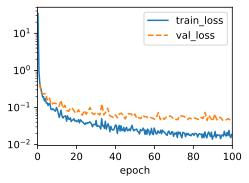

In [10]:
trainer = d2l.Trainer(max_epochs=100)
models = k_fold(trainer, data, k=5,
                model_fn=lambda: d2l.LinearRegression(lr=0.03))

Notice that sometimes the number of training errors
for a set of hyperparameters can be very low,
even as the number of errors on $K$-fold cross-validation
grows considerably higher.
This indicates that we are overfitting.
Throughout training you will want to monitor both numbers.
Less overfitting might indicate that our data can support a more powerful model.
Massive overfitting might suggest that we can gain
by incorporating regularization techniques.

##  Submitting Predictions on Kaggle

Now that we know what a good choice of hyperparameters should be,
we might 
calculate the average predictions 
on the test set
by all the $K$ models.
Since the models predict *log*-prices and the competition scores
root-mean-squared *log* error,
we average in log space before exponentiating:
the mean of the log-predictions is the ensemble
consistent with the metric
(in price space it amounts to a geometric mean).

Note what this *fold ensembling* is, though. Each of the $K$
models saw only $(K-1)/K$ of the training data, and the "average validation
log mse" we computed above estimates the error of a *single* such model, not
of the ensemble we are about to submit, whose error the cross-validation
score does not measure. The canonical alternative is to *refit* one model on
all of the training data using the hyperparameters that cross-validation
selected, so that the submitted model is a fresh draw of exactly the thing we
scored. Fold ensembling is standard Kaggle practice: it is free (the $K$
models are already trained) and the averaging usually buys a small variance
reduction, so it tends to edge out the refit. But the refit is the more
direct experiment, and you should choose between them deliberately.

Saving the predictions in a csv file
will simplify uploading the results to Kaggle.
The following code will generate a file called `submission.csv`.

In [11]:
preds = [model(d2l.tensor(test.values.astype(float), dtype=d2l.float32))
         for model, test in models]
# Average the K log-price predictions in log space, then exponentiate.
ensemble_preds = d2l.exp(d2l.reduce_mean(d2l.concat(preds, 1), 1))
submission = pd.DataFrame({'Id':data.raw_val.Id,
                           'SalePrice':d2l.numpy(ensemble_preds)})
submission.to_csv('submission.csv', index=False)

Next, as demonstrated in the figure,
we can submit our predictions on Kaggle
and see how they compare with the actual house prices (labels)
on the test set.
The steps are quite simple:

* Log in to the Kaggle website and visit the house price prediction competition page.
* Click the “Submit Predictions” or “Late Submission” button.
* Click the “Upload Submission File” button in the dashed box at the bottom of the page and select the prediction file you wish to upload.
* Click the “Make Submission” button at the bottom of the page to view your results.

![Submitting data to Kaggle.](https://raw.githubusercontent.com/smolix/d2l-neu/notebooks/img/kaggle-submit2.png)

## Summary and Discussion

Real data is messy: a mix of numeric and categorical features, with missing
values and wildly different scales. The preprocessing pipeline in this
section (mean imputation, standardization with statistics fit on the training
set only to avoid test-set leakage, and one-hot encoding of categoricals) is
a sensible default that applies far beyond this competition. When the target
spans an order of magnitude, predicting the *logarithm* of the price and
scoring with root-mean-squared log error converts an asymmetric dollar-scale
problem into one where a $10\%$ error on a $\$100{,}000$ house and on a
$\$1{,}000{,}000$ house are penalized equally, which is what we actually care
about.

$K$-fold cross-validation is useful for limited IID data such as this dataset:
it spends $K$ training runs to reduce dependence on one validation split, and
the same loop supports hyperparameter search. Random folds are invalid when
rows are grouped, ordered in time, spatially dependent, or otherwise linked;
those settings require a split that preserves the dependence structure.

Two caveats belong in any account of this pipeline. First, none of it is
specific to neural networks: the same preprocessing, loss design, and
cross-validation loop work with any model class, including the
gradient-boosted tree ensembles (XGBoost, LightGBM) that routinely beat deep
networks on medium-sized tabular data
[@Grinsztajn.Oyallon.Varoquaux.2022; @Shwartz-Ziv.Armon.2022]. Second,
model capacity matters: adding hidden layers, tuning the dropout rate, and
searching over learning rate and weight decay can improve substantially on
the baseline shown here, which is exactly what the exercises ask you to do.

Looking ahead, the moves we made here recur throughout supervised learning.
Feature scaling and imputation reappear in nearly every tabular pipeline, and
the competition recipe (download, preprocess, match the loss to the metric,
cross-validate, refit, submit) generalizes directly: later chapters apply the
same cross-validation discipline to image datasets, sequence tasks, and the
fine-tuning of pretrained models.


## Exercises

1. Submit your predictions for this section to Kaggle. How good are they?
1. Is it always a good idea to replace missing values by a mean? Hint: can you construct a situation where the values are not missing at random?
1. Improve the score by tuning the hyperparameters through $K$-fold cross-validation.
1. Improve the score by improving the model (e.g., layers, weight decay, and dropout).
1. What happens if we do not standardize the continuous numerical features as we have done in this section?
1. Swap the linear model for a gradient-boosted tree model (for example scikit-learn's `GradientBoostingRegressor`, or XGBoost or LightGBM if installed), trained on the same preprocessed features. How does its cross-validated log-RMSE compare? Why might tree ensembles have an edge on data like this?
1. Revisit the preprocessing choices. How does median imputation compare to mean imputation? What changes if you encode high-cardinality categorical features with target encoding or a learned embedding instead of one-hot vectors? Target encoding uses labels, so implement it out of fold: for each training row, its encoded value must be computed without that row or its validation fold.

[Discussions](https://d2l.discourse.group/t/237)